ARIEL DATA CHALLENGE 2025 - WITH ELEMENT IDENTIFICATION
📂 Loading datasets...
✅ Loaded: 1100 train samples, 1 test samples

FEATURE EXTRACTION

📊 Preparing train dataset...
Processing 1100 planets from /kaggle/input/ariel-data-challenge-2025/train/
  [1100/1100] Planet 4294092928
✅ Feature extraction complete
📦 Final shapes: X=(1210, 183), y=(1210, 283)
💾 Saved datasets to /kaggle/working/
   X: (1210, 183), y: (1210, 283), merged: (1210, 466)

MODEL TRAINING

🚀 Training with 5-fold CV
   Features: 183, Targets: 283

🔁 Fold 1/5


Training wavelengths: 100%|██████████| 283/283 [03:16<00:00,  1.44it/s]



🔁 Fold 2/5


Training wavelengths: 100%|██████████| 283/283 [03:01<00:00,  1.56it/s]



🔁 Fold 3/5


...


🔁 Fold 5/5


Training wavelengths: 100%|██████████| 283/283 [03:14<00:00,  1.46it/s]



📊 CV Performance:
   Mean R²:   0.9688
   Mean RMSE: 0.0019

🔍 Feature Importance Analysis

Top 15 features:
   6. P                                        198.5611
   8. i                                        189.9640
  117. autocorr_strongest_peak                  182.8806
  176. segment3_trend                           173.9640
  88. num_dip_periods                          172.9442
  164. segment0_trend                           140.0438
  95. transit_depth_std                        109.6622
  97. transit_flatness                         109.5230
  155. flux_diff2_mean                          98.7208
   4. Mp                                       90.9145
   7. sma                                      86.9915
   3. Ts                                       83.4806
  91. deepest_time_fraction                    77.3329
  107. fft_low_freq_ratio                       75.6000
  13. global_flux_skew                         68.9682

Feature categories:
  other          :   8 features

Wavelengths: 100%|██████████| 283/283 [02:29<00:00,  1.90λ/s]


✅ Optimization complete
⚠️  Official scorer not available, using fast approximation
🎯 Calibrated GLL Score: 0.241697

SUBMISSION & COMPOSITION ANALYSIS

📝 Creating submission...

📊 Preparing test dataset...
Processing 1 planets from /kaggle/input/ariel-data-challenge-2025/test/
  [1/1] Planet 1103775
✅ Feature extraction complete
📦 Final shape: X_test=(2, 183)

🔬 Atmospheric Composition Analysis
  Analyzing planet 1/1
  Completed analysis for 1 planets
💾 Saved composition analysis to: test_atmospheric_composition.csv

📊 Detection Statistics:
   Planets analyzed: 1
   Average elements detected: 6.0
    H2O: detected in    1 planets (avg conf: 0.31)
    CO2: detected in    1 planets (avg conf: 0.51)
    CH4: detected in    1 planets (avg conf: 0.65)
✅ Submission saved: submission.csv
   Shape: (1, 567)

✅ PIPELINE COMPLETE WITH ELEMENT IDENTIFICATION

📝 Generating composition report...
   ✅ Report saved to: test_composition_report.txt

📊 Creating composition heatmap...
   💾 Saved: atmosp

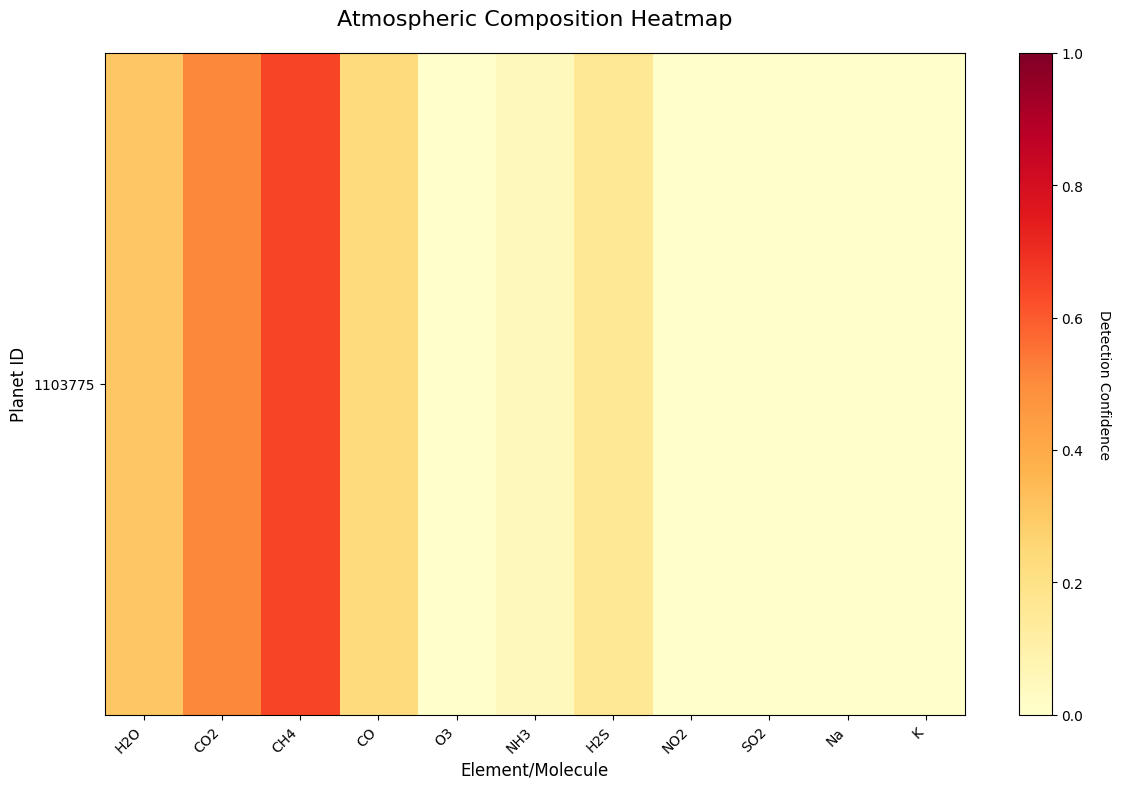


📚 AVAILABLE ANALYSIS FUNCTIONS:
  - example_analyze_single_planet(results, planet_id)
  - example_compare_planets(results, [planet_id1, planet_id2, ...])
  - find_similar_atmospheres(results['test_composition'], planet_id)
  - visualize_spectrum_with_elements(spectrum, planet_id, detections)


In [1]:
import os
import sys
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from scipy import signal, stats
from scipy.stats import skew, kurtosis, norm
from scipy.optimize import minimize_scalar
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm

warnings.filterwarnings('ignore')

# ============================================================================
# ELEMENT IDENTIFICATION DATABASE
# ============================================================================

class ElementDatabase:
    """Database of molecular and atomic absorption features"""
    
    # Wavelength ranges in micrometers with approximate absorption strengths
    SPECTRAL_FEATURES = {
        # Water vapor bands
        'H2O': [
            {'range': (0.90, 1.00), 'strength': 'strong', 'name': 'H2O_0.9um'},
            {'range': (1.10, 1.20), 'strength': 'medium', 'name': 'H2O_1.1um'},
            {'range': (1.35, 1.45), 'strength': 'strong', 'name': 'H2O_1.4um'},
            {'range': (1.80, 2.00), 'strength': 'strong', 'name': 'H2O_1.9um'},
            {'range': (2.50, 2.90), 'strength': 'very_strong', 'name': 'H2O_2.7um'},
            {'range': (5.50, 7.50), 'strength': 'very_strong', 'name': 'H2O_6.5um'},
        ],
        
        # Carbon dioxide
        'CO2': [
            {'range': (1.95, 2.10), 'strength': 'medium', 'name': 'CO2_2.0um'},
            {'range': (2.60, 2.80), 'strength': 'strong', 'name': 'CO2_2.7um'},
            {'range': (4.20, 4.40), 'strength': 'very_strong', 'name': 'CO2_4.3um'},
            {'range': (14.5, 16.0), 'strength': 'very_strong', 'name': 'CO2_15um'},
        ],
        
        # Methane
        'CH4': [
            {'range': (1.60, 1.80), 'strength': 'medium', 'name': 'CH4_1.7um'},
            {'range': (2.20, 2.50), 'strength': 'strong', 'name': 'CH4_2.3um'},
            {'range': (3.20, 3.50), 'strength': 'very_strong', 'name': 'CH4_3.3um'},
            {'range': (7.50, 8.00), 'strength': 'strong', 'name': 'CH4_7.7um'},
        ],
        
        # Carbon monoxide
        'CO': [
            {'range': (2.29, 2.40), 'strength': 'medium', 'name': 'CO_2.3um'},
            {'range': (4.50, 4.80), 'strength': 'strong', 'name': 'CO_4.7um'},
        ],
        
        # Ozone
        'O3': [
            {'range': (9.40, 10.0), 'strength': 'very_strong', 'name': 'O3_9.6um'},
        ],
        
        # Ammonia
        'NH3': [
            {'range': (1.50, 1.60), 'strength': 'weak', 'name': 'NH3_1.5um'},
            {'range': (2.00, 2.30), 'strength': 'medium', 'name': 'NH3_2.1um'},
            {'range': (10.0, 11.0), 'strength': 'strong', 'name': 'NH3_10.5um'},
        ],
        
        # Hydrogen sulfide
        'H2S': [
            {'range': (1.50, 1.70), 'strength': 'weak', 'name': 'H2S_1.6um'},
            {'range': (2.50, 2.70), 'strength': 'medium', 'name': 'H2S_2.6um'},
        ],
        
        # Nitrogen dioxide
        'NO2': [
            {'range': (0.40, 0.50), 'strength': 'medium', 'name': 'NO2_0.45um'},
        ],
        
        # Sulfur dioxide
        'SO2': [
            {'range': (0.28, 0.32), 'strength': 'strong', 'name': 'SO2_0.3um'},
            {'range': (7.00, 8.50), 'strength': 'strong', 'name': 'SO2_7.5um'},
        ],
        
        # Atomic sodium
        'Na': [
            {'range': (0.589, 0.590), 'strength': 'very_strong', 'name': 'Na_D_line'},
        ],
        
        # Atomic potassium
        'K': [
            {'range': (0.766, 0.770), 'strength': 'strong', 'name': 'K_doublet'},
        ],
    }
    
    @classmethod
    def get_wavelength_grid(cls, n_wavelengths=283):
        """Generate wavelength grid matching ARIEL observations"""
        # ARIEL wavelength range: ~0.5 to ~7.8 micrometers
        return np.linspace(0.5, 7.8, n_wavelengths)
    
    @classmethod
    def identify_features(cls, spectrum, wavelengths=None, threshold=0.02):
        """
        Identify absorption/emission features in a spectrum
        
        Args:
            spectrum: Array of spectral intensities
            wavelengths: Wavelength grid (micrometers)
            threshold: Detection threshold for feature strength
            
        Returns:
            Dictionary of detected elements with confidence scores
        """
        if wavelengths is None:
            wavelengths = cls.get_wavelength_grid(len(spectrum))
        
        # Normalize spectrum
        spectrum_norm = (spectrum - np.min(spectrum)) / (np.max(spectrum) - np.min(spectrum) + 1e-9)
        
        # Compute absorption depth (looking for dips)
        median_level = np.median(spectrum_norm)
        absorption = median_level - spectrum_norm
        
        detections = {}
        
        for element, features in cls.SPECTRAL_FEATURES.items():
            element_score = 0
            feature_detections = []
            
            for feature in features:
                wl_min, wl_max = feature['range']
                
                # Find indices in range
                mask = (wavelengths >= wl_min) & (wavelengths <= wl_max)
                
                if not np.any(mask):
                    continue
                
                # Measure absorption in this range
                region_absorption = absorption[mask]
                mean_absorption = np.mean(region_absorption)
                max_absorption = np.max(region_absorption)
                
                # Score based on strength
                strength_weight = {
                    'weak': 0.5,
                    'medium': 1.0,
                    'strong': 1.5,
                    'very_strong': 2.0
                }.get(feature['strength'], 1.0)
                
                # Feature present if absorption exceeds threshold
                if mean_absorption > threshold:
                    feature_score = mean_absorption * strength_weight
                    element_score += feature_score
                    
                    feature_detections.append({
                        'name': feature['name'],
                        'wavelength_range': f"{wl_min}-{wl_max}",
                        'absorption_depth': float(mean_absorption),
                        'max_absorption': float(max_absorption),
                        'confidence': min(1.0, feature_score)
                    })
            
            if element_score > 0:
                detections[element] = {
                    'total_score': float(element_score),
                    'confidence': min(1.0, element_score / 2.0),  # Normalize
                    'num_features': len(feature_detections),
                    'features': feature_detections
                }
        
        return detections
    
    @classmethod
    def summarize_atmosphere(cls, detections, top_n=5):
        """Create a summary of detected atmospheric components"""
        if not detections:
            return "No clear spectral features detected"
        
        # Sort by confidence
        sorted_elements = sorted(
            detections.items(),
            key=lambda x: x[1]['confidence'],
            reverse=True
        )[:top_n]
        
        summary = []
        for element, data in sorted_elements:
            conf_pct = data['confidence'] * 100
            summary.append(f"{element} ({conf_pct:.1f}% confidence, {data['num_features']} features)")
        
        return " | ".join(summary)


# ============================================================================
# CONFIGURATION (keeping original + adding element detection)
# ============================================================================

class Config:
    """Central configuration for the pipeline"""
    BASE_PATH = '/kaggle/input/ariel-data-challenge-2025/'
    SAVE_DIR = '/kaggle/working'
    ADC_INFO_PATH = f'{BASE_PATH}adc_info.csv'
    
    # Data paths
    TRAIN_PATH = f'{BASE_PATH}train/'
    TEST_PATH = f'{BASE_PATH}test/'
    
    # Quick run settings (for testing)
    QUICK_RUN = False
    QUICK_RUN_SIZE = 200
    
    # Model hyperparameters
    LGBM_PARAMS = {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'num_leaves': 127,
        'max_depth': 8,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.02,
        'reg_lambda': 0.05,
        'random_state': 42,
        'verbose': -1
    }
    
    # Cross-validation
    N_SPLITS = 5
    RANDOM_STATE = 42
    
    # Sigma optimization
    SIGMA_BOUNDS = (0.25, 4.0)
    
    # GLL metric parameters
    FSG_SIGMA_TRUE = 1e-6
    AIRS_SIGMA_TRUE = 1e-5
    FGS_WEIGHT = 0.4
    
    # Element detection
    DETECTION_THRESHOLD = 0.02


# ============================================================================
# DATA LOADING (unchanged)
# ============================================================================

def load_data(config=Config):
    """Load all required datasets"""
    print("📂 Loading datasets...")
    
    train_df = pd.read_csv(f"{config.BASE_PATH}train.csv")
    train_star_info = pd.read_csv(f"{config.BASE_PATH}train_star_info.csv")
    test_star_info = pd.read_csv(f"{config.BASE_PATH}test_star_info.csv")
    
    # Disable quick run in submission mode
    if len(test_star_info) > 1:
        config.QUICK_RUN = False
    
    if config.QUICK_RUN:
        train_star_info = train_star_info.head(config.QUICK_RUN_SIZE)
        print(f"⚠️  Quick run mode: only loading {config.QUICK_RUN_SIZE} records")
    
    print(f"✅ Loaded: {len(train_df)} train samples, {len(test_star_info)} test samples")
    
    return train_df, train_star_info, test_star_info


# ============================================================================
# SIGNAL PROCESSING (unchanged)
# ============================================================================

def apply_adc_correction(signal_array, instrument='FGS1', adc_path=Config.ADC_INFO_PATH):
    """Apply ADC calibration to raw signal data"""
    adc_df = pd.read_csv(adc_path)
    
    gain_col = f"{instrument}_adc_gain"
    offset_col = f"{instrument}_adc_offset"
    
    if gain_col not in adc_df.columns or offset_col not in adc_df.columns:
        raise ValueError(f"Missing ADC columns for {instrument}")
    
    gain = adc_df.at[0, gain_col]
    offset = adc_df.at[0, offset_col]
    
    return signal_array.astype(np.float32) * gain + offset


def compute_total_flux(signal_data):
    """Compute total flux time series from 3D signal data"""
    return np.sum(signal_data, axis=(1, 2))


# ============================================================================
# FEATURE EXTRACTION (keeping all original features)
# ============================================================================

class FeatureExtractor:
    """Encapsulates all feature extraction methods"""
    
    @staticmethod
    def global_flux_features(total_flux):
        """Extract basic statistical features from flux time series"""
        features = {
            'global_flux_mean': np.mean(total_flux),
            'global_flux_std': np.std(total_flux),
            'global_flux_min': np.min(total_flux),
            'global_flux_max': np.max(total_flux),
            'global_flux_skew': skew(total_flux),
            'global_flux_kurtosis': kurtosis(total_flux),
        }
        
        features['global_flux_range'] = features['global_flux_max'] - features['global_flux_min']
        features['global_flux_cv'] = features['global_flux_std'] / features['global_flux_mean']
        features['global_flux_depth'] = features['global_flux_mean'] - features['global_flux_min']
        features['global_flux_depth_ratio'] = features['global_flux_depth'] / features['global_flux_mean']
        
        # Percentiles
        for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
            features[f'global_flux_p{p}'] = np.percentile(total_flux, p)
        
        return features
    
    @staticmethod
    def rolling_statistics_features(total_flux):
        """Extract rolling window statistics"""
        features = {}
        window_sizes = [50, 100, 500, 1000, 2000, 5000]
        
        for window in window_sizes:
            if window >= len(total_flux):
                continue
            
            series = pd.Series(total_flux)
            rolling_mean = series.rolling(window=window, center=True).mean().dropna()
            rolling_std = series.rolling(window=window, center=True).std().dropna()
            rolling_min = series.rolling(window=window, center=True).min().dropna()
            rolling_max = series.rolling(window=window, center=True).max().dropna()
            
            if len(rolling_mean) > 0:
                prefix = f'rolling{window}'
                features[f'{prefix}_mean_min'] = rolling_mean.min()
                features[f'{prefix}_mean_max'] = rolling_mean.max()
                features[f'{prefix}_mean_std'] = rolling_mean.std()
                features[f'{prefix}_mean_range'] = rolling_mean.max() - rolling_mean.min()
                features[f'{prefix}_std_mean'] = rolling_std.mean()
                features[f'{prefix}_std_max'] = rolling_std.max()
                features[f'{prefix}_deepest_dip'] = rolling_min.min()
                features[f'{prefix}_highest_peak'] = rolling_max.max()
                features[f'{prefix}_volatility'] = rolling_std.std()
        
        return features
    
    @staticmethod
    def transit_detection_features(total_flux):
        """Extract transit-specific features"""
        features = {}
        
        # Detrend
        baseline = pd.Series(total_flux).rolling(window=5000, center=True).median()
        baseline = baseline.fillna(method='bfill').fillna(method='ffill')
        detrended = total_flux - baseline
        
        features['detrended_min'] = np.min(detrended)
        features['detrended_std'] = np.std(detrended)
        features['detrended_skew'] = skew(detrended)
        features['detrended_neg_excursions'] = np.sum(detrended < -2 * np.std(detrended))
        features['detrended_deep_excursions'] = np.sum(detrended < -3 * np.std(detrended))
        
        # Transit period detection
        threshold = np.mean(total_flux) - 1.0 * np.std(total_flux)
        below_threshold = total_flux < threshold
        
        if np.any(below_threshold):
            diff = np.diff(np.concatenate(([False], below_threshold, [False])).astype(int))
            starts = np.where(diff == 1)[0]
            ends = np.where(diff == -1)[0]
            durations = ends - starts
            
            features['longest_dip_duration'] = np.max(durations) if len(durations) > 0 else 0
            features['num_dip_periods'] = len(durations)
            features['total_dip_time'] = np.sum(durations)
            features['avg_dip_duration'] = np.mean(durations) if len(durations) > 0 else 0
            
            deepest_idx = np.argmin(total_flux)
            features['deepest_time_fraction'] = deepest_idx / len(total_flux)
            features['deepest_in_first_half'] = float(deepest_idx < len(total_flux) / 2)
            features['deepest_in_middle_third'] = float(
                len(total_flux) / 3 < deepest_idx < 2 * len(total_flux) / 3
            )
            
            transit_flux = total_flux[below_threshold]
            features['transit_depth_mean'] = np.mean(transit_flux)
            features['transit_depth_std'] = np.std(transit_flux)
            features['transit_assymetry'] = skew(transit_flux)
            features['transit_flatness'] = kurtosis(transit_flux)
        else:
            features.update({
                'longest_dip_duration': 0, 'num_dip_periods': 0,
                'total_dip_time': 0, 'avg_dip_duration': 0,
                'deepest_time_fraction': 0.5, 'deepest_in_first_half': 0,
                'deepest_in_middle_third': 0, 'transit_depth_mean': np.mean(total_flux),
                'transit_depth_std': 0, 'transit_assymetry': 0, 'transit_flatness': 0
            })
        
        # Temporal segments
        n = len(total_flux)
        first_q = total_flux[:n//4]
        last_q = total_flux[-n//4:]
        middle = total_flux[n//4:-n//4]
        
        features['first_quarter_mean'] = np.mean(first_q)
        features['last_quarter_mean'] = np.mean(last_q)
        features['middle_half_mean'] = np.mean(middle)
        features['middle_vs_edges'] = (
            features['middle_half_mean'] - 
            (features['first_quarter_mean'] + features['last_quarter_mean']) / 2
        )
        
        return features
    
    @staticmethod
    def frequency_features(total_flux):
        """Extract frequency domain features"""
        features = {}
        
        # FFT
        fft_flux = np.fft.fft(total_flux - np.mean(total_flux))
        fft_power = np.abs(fft_flux)
        fft_freqs = np.fft.fftfreq(len(total_flux))
        
        power_spectrum = fft_power[1:len(fft_power)//2]
        freqs = np.abs(fft_freqs[1:len(fft_freqs)//2])
        
        features['fft_peak_power'] = np.max(power_spectrum)
        features['fft_total_power'] = np.sum(power_spectrum)
        features['fft_mean_power'] = np.mean(power_spectrum)
        features['fft_std_power'] = np.std(power_spectrum)
        
        low_freq_mask = np.abs(fft_freqs) < 0.01
        features['fft_low_freq_power'] = np.sum(fft_power[low_freq_mask])
        features['fft_low_freq_ratio'] = (
            features['fft_low_freq_power'] / features['fft_total_power']
        )
        
        if np.sum(power_spectrum) > 0:
            features['spectral_centroid'] = np.sum(freqs * power_spectrum) / np.sum(power_spectrum)
            features['spectral_bandwidth'] = np.sqrt(
                np.sum(((freqs - features['spectral_centroid'])**2) * power_spectrum) / 
                np.sum(power_spectrum)
            )
        else:
            features['spectral_centroid'] = 0
            features['spectral_bandwidth'] = 0
        
        # Autocorrelation
        autocorr = np.correlate(
            total_flux - np.mean(total_flux),
            total_flux - np.mean(total_flux),
            mode='full'
        )
        autocorr = autocorr[autocorr.size // 2:]
        autocorr = autocorr / autocorr[0]
        
        for lag in [10, 50, 100, 500, 1000]:
            if lag < len(autocorr):
                features[f'autocorr_lag{lag}'] = autocorr[lag]
        
        peaks, _ = signal.find_peaks(autocorr[1:1000], height=0.1)
        features['autocorr_num_peaks'] = len(peaks)
        features['autocorr_first_peak'] = peaks[0] if len(peaks) > 0 else 0
        features['autocorr_strongest_peak'] = np.max(autocorr[peaks]) if len(peaks) > 0 else 0
        
        return features
    
    @staticmethod
    def spatial_features(signal_data):
        """Extract spatial distribution features from image frames"""
        features = {}
        key_frames = [0, len(signal_data)//4, len(signal_data)//2, 3*len(signal_data)//4, -1]
        
        centroids_x, centroids_y, concentrations = [], [], []
        
        for i, idx in enumerate(key_frames):
            frame = signal_data[idx]
            y_indices, x_indices = np.indices(frame.shape)
            total = np.sum(frame)
            
            if total > 0:
                cx = np.sum(x_indices * frame) / total
                cy = np.sum(y_indices * frame) / total
            else:
                cx = cy = 16
            
            centroids_x.append(cx)
            centroids_y.append(cy)
            
            center_region = frame[12:20, 12:20]
            conc = np.sum(center_region) / total if total > 0 else 0
            concentrations.append(conc)
            
            features[f'frame{i}_spatial_mean'] = np.mean(frame)
            features[f'frame{i}_spatial_std'] = np.std(frame)
            features[f'frame{i}_centroid_x'] = cx
            features[f'frame{i}_centroid_y'] = cy
            features[f'frame{i}_concentration'] = conc
        
        features['centroid_x_range'] = np.max(centroids_x) - np.min(centroids_x)
        features['centroid_y_range'] = np.max(centroids_y) - np.min(centroids_y)
        features['centroid_total_movement'] = np.sum(
            np.sqrt(np.diff(centroids_x)**2 + np.diff(centroids_y)**2)
        )
        features['concentration_range'] = np.max(concentrations) - np.min(concentrations)
        features['concentration_std'] = np.std(concentrations)
        
        return features
    
    @staticmethod
    def gradient_features(total_flux):
        """Extract gradient and temporal change features"""
        features = {}
        total_flux = np.array(total_flux, dtype=np.float64)
        
        diff1 = np.diff(total_flux)
        diff2 = np.diff(diff1)
        
        features['flux_diff1_mean'] = np.mean(diff1)
        features['flux_diff1_std'] = np.std(diff1)
        features['flux_diff1_min'] = np.min(diff1)
        features['flux_diff1_max'] = np.max(diff1)
        features['flux_diff1_range'] = features['flux_diff1_max'] - features['flux_diff1_min']
        features['flux_diff1_skew'] = skew(diff1)
        features['flux_diff1_kurtosis'] = kurtosis(diff1)
        
        features['flux_diff2_mean'] = np.mean(diff2)
        features['flux_diff2_std'] = np.std(diff2)
        features['flux_diff2_extremes'] = np.sum(np.abs(diff2) > 3 * np.std(diff2))
        
        for window in [10, 50, 100]:
            if window < len(diff1):
                rolling_std = pd.Series(diff1).rolling(window=window).std()
                features[f'diff_volatility_w{window}_max'] = rolling_std.max()
                features[f'diff_volatility_w{window}_mean'] = rolling_std.mean()
        
        # Segment analysis
        n_segments = 4
        segment_size = len(total_flux) // n_segments
        segment_means = []
        
        for i in range(n_segments):
            start = i * segment_size
            end = (i + 1) * segment_size if i < n_segments - 1 else len(total_flux)
            seg = total_flux[start:end]
            
            if len(seg) > 1:
                trend = np.polyfit(np.arange(len(seg)), seg, 1)[0]
                features[f'segment{i}_trend'] = trend
                features[f'segment{i}_mean'] = np.mean(seg)
                features[f'segment{i}_std'] = np.std(seg)
                features[f'segment{i}_range'] = np.max(seg) - np.min(seg)
                segment_means.append(features[f'segment{i}_mean'])
        
        features['segment_mean_range'] = np.max(segment_means) - np.min(segment_means)
        features['segment_mean_std'] = np.std(segment_means)
        
        global_mean = np.mean(total_flux)
        global_std = np.std(total_flux)
        transit_segments = sum(1 for m in segment_means if m < global_mean - global_std)
        
        features['num_transit_segments'] = transit_segments
        features['transit_segment_fraction'] = transit_segments / n_segments
        
        return features
    
    @classmethod
    def extract_all_features(cls, signal_data, verbose=False):
        """Extract all feature categories from signal data"""
        signal_data = apply_adc_correction(signal_data, instrument='FGS1')
        total_flux = compute_total_flux(signal_data)
        
        if verbose:
            print(f"Extracting features from {signal_data.shape[0]} frames...")
        
        features = {}
        features.update(cls.global_flux_features(total_flux))
        features.update(cls.rolling_statistics_features(total_flux))
        features.update(cls.transit_detection_features(total_flux))
        features.update(cls.frequency_features(total_flux))
        features.update(cls.spatial_features(signal_data))
        features.update(cls.gradient_features(total_flux))
        
        if verbose:
            print(f"Generated {len(features)} features")
        
        return features


# ============================================================================
# DATA PREPARATION (unchanged except for prepare_dataset signature)
# ============================================================================

def prepare_dataset(train_df, star_info_df, data_path, is_test=False):
    """
    Prepare features and targets from raw signal data.
    Handles multiple signals per planet with unique IDs.
    """
    print(f"\n📊 Preparing {'test' if is_test else 'train'} dataset...")
    print(f"Processing {len(star_info_df)} planets from {data_path}")
    
    star_info_df = star_info_df.copy()
    star_info_df['planet_id'] = star_info_df['planet_id'].astype(str)
    
    if train_df is not None:
        train_df = train_df.copy()
        train_df['planet_id'] = train_df['planet_id'].astype(str)
    
    all_features = []
    
    for i, row in star_info_df.iterrows():
        base_id = int(float(row['planet_id']))
        print(f"\r  [{i+1}/{len(star_info_df)}] Planet {base_id}", end='', flush=True)
        
        try:
            signal_paths = sorted(glob.glob(f"{data_path}{base_id}/FGS1_signal_*.parquet"))
            
            for j, path in enumerate(signal_paths):
                df = pd.read_parquet(path)
                signal = df.values.reshape(135000, 32, 32)
                
                features = FeatureExtractor.extract_all_features(signal, verbose=False)
                features['planet_id'] = f"{base_id}_{j}"
                all_features.append(features)
                
        except Exception as e:
            print(f"\n❌ Error processing planet {base_id}: {e}")
            continue
    
    print("\n✅ Feature extraction complete")
    
    # Build features DataFrame
    features_df = pd.DataFrame(all_features)
    features_df['planet_id'] = features_df['planet_id'].astype(str)
    features_df = features_df.set_index('planet_id')
    
    # Expand star metadata for each signal
    star_info_df['planet_id'] = star_info_df['planet_id'].apply(
        lambda x: str(int(float(x)))
    )
    
    expanded_meta = []
    for pid in features_df.index:
        base_id = str(int(float(pid.split("_")[0])))
        row = star_info_df[star_info_df['planet_id'] == base_id].copy()
        if not row.empty:
            row['planet_id'] = pid
            expanded_meta.append(row)
    
    meta_df = pd.concat(expanded_meta, ignore_index=True).set_index('planet_id')
    
    # Merge metadata and features
    full_df = meta_df.join(features_df, how='left')
    X = full_df.select_dtypes(include=[np.number]).fillna(0).astype(np.float32)
    
    if not is_test and train_df is not None:
        # Create targets for training
        targets_df = train_df.set_index('planet_id')
        extended_targets = []
        
        for pid in X.index:
            base_id = pid.split("_")[0]
            if base_id in targets_df.index:
                y_row = targets_df.loc[base_id].copy()
                y_row.name = pid
                extended_targets.append(y_row)
        
        y = pd.DataFrame(extended_targets).astype(np.float32)
        print(f"📦 Final shapes: X={X.shape}, y={y.shape}")
        return X, y
    else:
        print(f"📦 Final shape: X_test={X.shape}")
        return X


def save_dataset(X, y=None, save_dir=Config.SAVE_DIR):
    """Save prepared datasets to CSV"""
    os.makedirs(save_dir, exist_ok=True)
    
    if y is not None:
        # Align indices
        common_idx = X.index.intersection(y.index)
        X = X.loc[common_idx].sort_index().astype('float32')
        y = y.loc[common_idx].sort_index().astype('float32')
        
        # Save
        X.to_csv(f"{save_dir}/fgs1_features_X.csv", index_label="planet_id")
        y.to_csv(f"{save_dir}/fgs1_targets_y.csv", index_label="planet_id")
        
        merged = pd.concat([y, X], axis=1)
        merged.to_csv(f"{save_dir}/fgs1_dataset_merged.csv", index_label="planet_id")
        
        print(f"💾 Saved datasets to {save_dir}/")
        print(f"   X: {X.shape}, y: {y.shape}, merged: {merged.shape}")


# ============================================================================
# MODEL TRAINING (unchanged)
# ============================================================================

class ModelTrainer:
    """Handles model training with cross-validation"""
    
    def __init__(self, n_splits=Config.N_SPLITS, lgbm_params=None):
        self.n_splits = n_splits
        self.lgbm_params = lgbm_params or Config.LGBM_PARAMS
        
    def train_cv(self, X, y):
        """Train multi-output models with K-fold cross-validation"""
        print(f"\n🚀 Training with {self.n_splits}-fold CV")
        print(f"   Features: {X.shape[1]}, Targets: {y.shape[1]}")
        
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=Config.RANDOM_STATE)
        
        all_models = [[] for _ in range(y.shape[1])]
        oof_preds = np.zeros_like(y.values, dtype=float)
        oof_sigmas = np.zeros_like(y.values, dtype=float)
        residuals_all = [[] for _ in range(y.shape[1])]
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
            print(f"\n🔁 Fold {fold+1}/{self.n_splits}")
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            for i in tqdm(range(y.shape[1]), desc="Training wavelengths"):
                model = lgb.LGBMRegressor(**self.lgbm_params)
                y_single = y_train.iloc[:, i]
                
                model.fit(X_train, y_single)
                all_models[i].append(model)
                
                # OOF predictions
                pred_val = model.predict(X_val)
                oof_preds[val_idx, i] = pred_val
                
                # Collect residuals
                pred_train = model.predict(X_train)
                residuals = y_single - pred_train
                residuals_all[i].extend(residuals.tolist())
                
                sigma = np.std(residuals)
                oof_sigmas[val_idx, i] = max(sigma, 1e-6)
        
        # Final uncertainties from all residuals
        target_uncertainties = [max(np.std(res), 1e-6) for res in residuals_all]
        
        # Compute metrics
        r2_scores = [r2_score(y.values[:, i], oof_preds[:, i]) for i in range(y.shape[1])]
        rmses = [
            mean_squared_error(y.values[:, i], oof_preds[:, i], squared=False)
            for i in range(y.shape[1])
        ]
        
        print(f"\n📊 CV Performance:")
        print(f"   Mean R²:   {np.mean(r2_scores):.4f}")
        print(f"   Mean RMSE: {np.mean(rmses):.4f}")
        
        return {
            'models': all_models,
            'feature_columns': X.columns.tolist(),
            'target_columns': y.columns.tolist(),
            'oof_predictions': oof_preds,
            'oof_uncertainties': oof_sigmas,
            'y_true': y.values,
            'target_uncertainties': target_uncertainties,
            'cv_metrics': {
                'r2_per_target': r2_scores,
                'rmse_per_target': rmses,
                'mean_r2': np.mean(r2_scores),
                'mean_rmse': np.mean(rmses)
            }
        }


# ============================================================================
# FEATURE IMPORTANCE ANALYSIS (unchanged)
# ============================================================================

def analyze_feature_importance(trained_models, X, save_path='feature_importance.csv'):
    """Analyze and save feature importance"""
    print("\n🔍 Feature Importance Analysis")
    
    all_models_flat = [
        m for models_per_target in trained_models['models'] for m in models_per_target
    ]
    
    importance_df = pd.DataFrame({
        'feature': trained_models['feature_columns'],
        'importance': np.mean([m.feature_importances_ for m in all_models_flat], axis=0)
    }).sort_values('importance', ascending=False)
    
    print("\nTop 15 features:")
    for i, row in importance_df.head(15).iterrows():
        print(f"  {i+1:2d}. {row['feature']:<40} {row['importance']:.4f}")
    
    # Category analysis
    categories = {}
    for _, row in importance_df.iterrows():
        cat = row['feature'].split('_')[0] if '_' in row['feature'] else 'other'
        categories.setdefault(cat, []).append(row['importance'])
    
    print("\nFeature categories:")
    for cat, imps in sorted(categories.items(), key=lambda x: np.sum(x[1]), reverse=True):
        contrib = np.sum(imps) / importance_df['importance'].sum() * 100
        print(f"  {cat:<15}: {len(imps):>3d} features, {contrib:>5.1f}% contribution")
    
    importance_df.to_csv(save_path, index=False)
    print(f"\n💾 Saved to: {save_path}")
    
    return importance_df


# ============================================================================
# PREDICTION & UNCERTAINTY (unchanged)
# ============================================================================

def predict_with_uncertainty(models, X, target_uncertainties=None):
    """Make predictions with uncertainty estimates"""
    n_targets = len(models)
    is_cv = isinstance(models[0], list)
    
    predictions = []
    uncertainties = []
    
    for i in range(n_targets):
        model_group = models[i] if is_cv else [models[i]]
        preds = [m.predict(X) for m in model_group]
        pred_avg = np.mean(preds, axis=0)
        predictions.append(pred_avg)
        
        unc = target_uncertainties[i] if target_uncertainties else 0.01
        unc_array = np.full_like(pred_avg, max(unc, 1e-6))
        uncertainties.append(unc_array)
    
    y_pred = np.column_stack(predictions)
    sigma_pred = np.column_stack(uncertainties)
    
    # Clean predictions
    pred_df = pd.DataFrame(y_pred).apply(pd.to_numeric, errors='coerce').fillna(0).clip(lower=0)
    sigma_df = pd.DataFrame(sigma_pred).apply(pd.to_numeric, errors='coerce').fillna(1e-6).clip(lower=1e-15)
    
    return pred_df.values, sigma_df.values


# ============================================================================
# GLL METRIC EVALUATION (unchanged)
# ============================================================================

def fast_gll_score(y_true, y_pred, sigma_pred, naive_mean, naive_sigma,
                   fsg_sigma_true=Config.FSG_SIGMA_TRUE,
                   airs_sigma_true=Config.AIRS_SIGMA_TRUE,
                   fgs_weight=Config.FGS_WEIGHT):
    """Fast NumPy-based Gaussian Log Likelihood score"""
    sigma_pred = np.clip(sigma_pred, 1e-15, None)
    n_samples, n_waves = sigma_pred.shape
    
    sigma_true = np.append([fsg_sigma_true], np.full(n_waves - 1, airs_sigma_true))
    sigma_true = np.tile(sigma_true, (n_samples, 1))
    
    weights = np.append([fgs_weight], np.ones(n_waves - 1))
    weights = np.tile(weights, (n_samples, 1))
    
    gll_pred = norm.logpdf(y_true, loc=y_pred, scale=sigma_pred)
    gll_true = norm.logpdf(y_true, loc=y_true, scale=sigma_true)
    gll_naive = norm.logpdf(y_true, loc=naive_mean, scale=naive_sigma)
    
    ind_scores = (gll_pred - gll_naive) / (gll_true - gll_naive + 1e-9)
    final_score = np.average(ind_scores, weights=weights)
    
    return float(np.clip(final_score, 0.0, 1.0))


def evaluate_gll_metric(y_true, y_pred, sigma_pred, naive_mean, naive_sigma):
    """Evaluate using official GLL metric with proper formatting"""
    if not isinstance(y_true, pd.DataFrame):
        y_true = pd.DataFrame(y_true)
    
    y_true = y_true.reset_index(drop=True)
    n_samples, n_waves = y_pred.shape
    
    sigma_pred = np.clip(sigma_pred, 1e-15, None)
    
    # Format for official scorer
    solution_df = y_true.copy()
    solution_df['row_id'] = np.arange(n_samples)
    
    submission_df = pd.DataFrame()
    for i in range(n_waves):
        submission_df[f'wavelength_{i}'] = y_pred[:, i]
    for i in range(n_waves):
        submission_df[f'wavelength_{i}_std'] = sigma_pred[:, i]
    submission_df['row_id'] = np.arange(n_samples)
    submission_df = submission_df.clip(lower=1e-15)
    
    try:
        sys.path.append('/kaggle/usr/lib/ariel-gaussian-log-likelihood')
        from metric import score
        
        gll = score(
            solution=solution_df,
            submission=submission_df,
            row_id_column_name='row_id',
            naive_mean=naive_mean,
            naive_sigma=naive_sigma,
            fsg_sigma_true=Config.FSG_SIGMA_TRUE,
            airs_sigma_true=Config.AIRS_SIGMA_TRUE,
            fgs_weight=Config.FGS_WEIGHT
        )
    except ImportError:
        print("⚠️  Official scorer not available, using fast approximation")
        gll = fast_gll_score(y_true.values, y_pred, sigma_pred, naive_mean, naive_sigma)
    
    return gll


# ============================================================================
# SIGMA CALIBRATION (unchanged)
# ============================================================================

class SigmaOptimizer:
    """Optimize sigma scaling factors per wavelength"""
    
    def __init__(self, bounds=Config.SIGMA_BOUNDS):
        self.bounds = bounds
    
    def optimize(self, y_true, y_pred, sigma_pred, naive_mean, naive_sigma):
        """Optimize per-wavelength sigma scalers"""
        n_waves = sigma_pred.shape[1]
        best_scales = np.ones(n_waves)
        
        print(f"\n⚡ Optimizing {n_waves} sigma scalers...")
        
        for i in tqdm(range(n_waves), desc="Wavelengths", unit="λ"):
            def objective(scale):
                sigma_scaled = sigma_pred.copy()
                sigma_scaled[:, i] *= scale
                return -fast_gll_score(
                    y_true, y_pred, sigma_scaled,
                    naive_mean, naive_sigma
                )
            
            result = minimize_scalar(objective, bounds=self.bounds, method='bounded')
            best_scales[i] = result.x
        
        print("✅ Optimization complete")
        return best_scales


# ============================================================================
# ELEMENT IDENTIFICATION ANALYSIS
# ============================================================================

def analyze_atmospheric_composition(predictions_df, planet_ids=None, 
                                   save_path='atmospheric_composition.csv'):
    """
    Analyze predicted spectra to identify atmospheric elements/molecules
    
    Args:
        predictions_df: DataFrame with predicted wavelength intensities
        planet_ids: Optional list of planet IDs to analyze
        save_path: Path to save composition results
    
    Returns:
        DataFrame with detected elements per planet
    """
    print("\n🔬 Atmospheric Composition Analysis")
    print("=" * 80)
    
    wavelengths = ElementDatabase.get_wavelength_grid(predictions_df.shape[1])
    
    if planet_ids is None:
        planet_ids = predictions_df.index
    
    results = []
    
    for i, planet_id in enumerate(planet_ids):
        if i % 10 == 0:
            print(f"  Analyzing planet {i+1}/{len(planet_ids)}", end='\r')
        
        spectrum = predictions_df.loc[planet_id].values
        
        # Detect elements
        detections = ElementDatabase.identify_features(
            spectrum, 
            wavelengths, 
            threshold=Config.DETECTION_THRESHOLD
        )
        
        # Create summary
        summary = ElementDatabase.summarize_atmosphere(detections, top_n=5)
        
        # Store result
        result = {
            'planet_id': planet_id,
            'num_detected': len(detections),
            'composition_summary': summary
        }
        
        # Add individual element confidences
        for element in ['H2O', 'CO2', 'CH4', 'CO', 'O3', 'NH3', 'H2S', 'NO2', 'SO2', 'Na', 'K']:
            if element in detections:
                result[f'{element}_confidence'] = detections[element]['confidence']
                result[f'{element}_features'] = detections[element]['num_features']
            else:
                result[f'{element}_confidence'] = 0.0
                result[f'{element}_features'] = 0
        
        results.append(result)
    
    print(f"\n  Completed analysis for {len(planet_ids)} planets")
    
    # Create results DataFrame
    composition_df = pd.DataFrame(results).set_index('planet_id')
    
    # Save to CSV
    composition_df.to_csv(save_path)
    print(f"💾 Saved composition analysis to: {save_path}")
    
    # Print summary statistics
    print("\n📊 Detection Statistics:")
    print(f"   Planets analyzed: {len(composition_df)}")
    print(f"   Average elements detected: {composition_df['num_detected'].mean():.1f}")
    
    # Most common elements
    element_cols = [col for col in composition_df.columns if col.endswith('_confidence')]
    for col in element_cols:
        element = col.replace('_confidence', '')
        detected_count = (composition_df[col] > 0.3).sum()
        if detected_count > 0:
            avg_conf = composition_df[composition_df[col] > 0.3][col].mean()
            print(f"   {element:>4s}: detected in {detected_count:>4d} planets (avg conf: {avg_conf:.2f})")
    
    return composition_df


def visualize_spectrum_with_elements(spectrum, planet_id, detections=None, save_fig=False):
    """
    Visualize a spectrum with detected element markers
    
    Args:
        spectrum: Array of spectral intensities
        planet_id: Planet identifier
        detections: Dictionary of detected elements (from ElementDatabase.identify_features)
        save_fig: Whether to save the figure
    """
    wavelengths = ElementDatabase.get_wavelength_grid(len(spectrum))
    
    plt.figure(figsize=(16, 8))
    
    # Plot spectrum
    plt.plot(wavelengths, spectrum, 'b-', linewidth=2, label='Observed Spectrum', alpha=0.7)
    
    # Mark detected features
    if detections:
        colors = plt.cm.Set3(np.linspace(0, 1, len(detections)))
        
        for (element, data), color in zip(detections.items(), colors):
            for feature in data['features']:
                wl_range = feature['wavelength_range'].split('-')
                wl_min, wl_max = float(wl_range[0]), float(wl_range[1])
                
                # Highlight region
                mask = (wavelengths >= wl_min) & (wavelengths <= wl_max)
                if np.any(mask):
                    plt.axvspan(wl_min, wl_max, alpha=0.2, color=color, 
                               label=f"{element} ({feature['name']})")
                    
                    # Add marker at deepest point
                    region_spectrum = spectrum[mask]
                    if len(region_spectrum) > 0:
                        min_idx = np.argmin(region_spectrum)
                        wl_at_min = wavelengths[mask][min_idx]
                        plt.plot(wl_at_min, region_spectrum[min_idx], 'o', 
                                color=color, markersize=8, markeredgecolor='black')
    
    plt.xlabel('Wavelength (μm)', fontsize=14)
    plt.ylabel('Intensity (normalized)', fontsize=14)
    plt.title(f'Atmospheric Spectrum - Planet {planet_id}', fontsize=16, pad=20)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    
    if save_fig:
        plt.savefig(f'spectrum_planet_{planet_id}.png', dpi=150, bbox_inches='tight')
    
    plt.show()
    
    # Print detection summary
    if detections:
        print(f"\n🌍 Planet {planet_id} Atmospheric Composition:")
        print("=" * 70)
        for element, data in sorted(detections.items(), 
                                   key=lambda x: x[1]['confidence'], 
                                   reverse=True):
            print(f"  {element:>4s}: {data['confidence']*100:5.1f}% confidence, "
                  f"{data['num_features']} features detected")
            for feat in data['features'][:3]:  # Show top 3 features
                print(f"        - {feat['name']}: depth={feat['absorption_depth']:.4f}")


# ============================================================================
# SUBMISSION GENERATION (modified to include composition)
# ============================================================================

def create_submission(trained_models, test_star_info, sigma_scalers=None,
                     output_path='submission.csv',
                     analyze_composition=True):
    """Generate submission file from test data with optional composition analysis"""
    print("\n📝 Creating submission...")
    
    # Prepare test features
    X_test = prepare_dataset(
        train_df=None,
        star_info_df=test_star_info,
        data_path=Config.TEST_PATH,
        is_test=True
    )
    
    # Align columns with training
    X_test_aligned = X_test.reindex(columns=trained_models['feature_columns'], fill_value=0)
    
    # Predict
    y_pred, sigma_pred = predict_with_uncertainty(
        trained_models['models'],
        X_test_aligned,
        target_uncertainties=trained_models['target_uncertainties']
    )
    
    # Apply sigma scaling
    if sigma_scalers is not None:
        sigma_pred = sigma_pred * sigma_scalers
    
    # Parse base planet IDs from signal IDs
    base_ids = [idx.split("_")[0] for idx in X_test_aligned.index]
    
    # Create DataFrames
    wl_cols = trained_models['target_columns']
    sigma_cols = [f"sigma_{i+1}" for i in range(y_pred.shape[1])]
    
    pred_df = pd.DataFrame(y_pred, index=base_ids, columns=wl_cols)
    sigma_df = pd.DataFrame(sigma_pred, index=base_ids, columns=sigma_cols)
    
    # Average predictions per planet
    pred_mean = pred_df.groupby(pred_df.index).mean()
    sigma_mean = sigma_df.groupby(sigma_df.index).mean()
    
    # Analyze atmospheric composition
    if analyze_composition:
        composition_df = analyze_atmospheric_composition(
            pred_mean, 
            save_path='test_atmospheric_composition.csv'
        )
    
    # Build submission
    submission = pd.concat([pred_mean, sigma_mean], axis=1).reset_index()
    submission = submission.rename(columns={'index': 'planet_id'})
    submission['planet_id'] = submission['planet_id'].astype(int)
    
    # Save
    submission.to_csv(output_path, index=False, float_format='%.5f')
    print(f"✅ Submission saved: {output_path}")
    print(f"   Shape: {submission.shape}")
    
    return submission, composition_df if analyze_composition else None


# ============================================================================
# VISUALIZATION (enhanced)
# ============================================================================

def visualize_transit(signal_data, planet_id, save_fig=False):
    """Visualize transit event with frames and light curve"""
    signal_data = apply_adc_correction(signal_data, instrument='FGS1')
    total_flux = compute_total_flux(signal_data)
    
    # Select key frames
    base_frames = [0, len(signal_data)//4, len(signal_data)//2, 
                   3*len(signal_data)//4, -1]
    brightest_idx = np.argmax(total_flux)
    darkest_idx = np.argmin(total_flux)
    
    frames = base_frames + [idx for idx in [brightest_idx, darkest_idx] 
                            if idx not in base_frames and idx != len(signal_data)-1]
    
    # Setup plot
    plt.style.use('default')
    fig = plt.figure(figsize=(18, 10))
    
    # Top row: frames
    for i, idx in enumerate(frames):
        ax = plt.subplot(2, len(frames), i + 1)
        frame = signal_data[idx]
        
        vmin, vmax = np.percentile(frame, [2, 98])
        ax.imshow(frame, cmap='hot', aspect='equal', vmin=vmin, vmax=vmax)
        
        time_min = idx * 0.1 / 60
        title = 'Brightest' if idx == brightest_idx else 'Darkest' if idx == darkest_idx else ''
        title += f'\nT={time_min:.1f} min'
        ax.set_title(title, fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Bottom: light curve
    ax_light = plt.subplot(2, 1, 2)
    time_hours = np.arange(len(total_flux)) * 0.1 / 3600
    sample = slice(None, None, max(1, len(total_flux)//2000))
    
    ax_light.plot(time_hours[sample], total_flux[sample], 
                 color='lightsteelblue', alpha=0.4, linewidth=0.5, label='Raw flux')
    
    window = 500
    moving_avg = pd.Series(total_flux).rolling(window, center=True).mean()
    ax_light.plot(time_hours[sample], moving_avg.iloc[sample], 
                 color='darkblue', linewidth=3, label=f'{window}-frame average')
    
    colors = ['red', 'orange', 'green', 'purple', 'brown', 'lime', 'black']
    for i, idx in enumerate(frames):
        ax_light.axvline(idx * 0.1 / 3600, color=colors[i % len(colors)], 
                        alpha=0.8, linewidth=1.5, linestyle='--')
    
    ax_light.set_xlabel('Time (hours)', fontsize=12)
    ax_light.set_ylabel('Total Flux (counts)', fontsize=12)
    ax_light.set_title(f'Transit Light Curve - Planet {planet_id}', fontsize=14, pad=15)
    ax_light.grid(True, alpha=0.3)
    ax_light.legend(loc='upper right', framealpha=0.9)
    
    plt.tight_layout(pad=2.0)
    
    if save_fig:
        plt.savefig(f'transit_planet_{planet_id}.png', dpi=150, bbox_inches='tight')
    
    plt.show()
    
    # Print summary
    duration = time_hours[-1]
    transit_depth = np.mean(total_flux) - np.min(total_flux)
    print(f"\n🌟 Planet {planet_id} Transit Summary:")
    print(f"   Duration: {duration:.2f} hours ({len(signal_data):,} frames)")
    print(f"   Brightness range: {np.min(total_flux):,.0f} → {np.max(total_flux):,.0f}")
    print(f"   Transit depth: {transit_depth:,.0f} ({transit_depth/np.mean(total_flux)*100:.3f}%)")


# ============================================================================
# MAIN PIPELINE (enhanced)
# ============================================================================

def main():
    """Main training and evaluation pipeline with element identification"""
    print("="*80)
    print("ARIEL DATA CHALLENGE 2025 - WITH ELEMENT IDENTIFICATION")
    print("="*80)
    
    # Load data
    train_df, train_star_info, test_star_info = load_data()
    
    # Prepare datasets
    print("\n" + "="*80)
    print("FEATURE EXTRACTION")
    print("="*80)
    X, y = prepare_dataset(train_df, train_star_info, Config.TRAIN_PATH)
    save_dataset(X, y)
    
    # Train models
    print("\n" + "="*80)
    print("MODEL TRAINING")
    print("="*80)
    trainer = ModelTrainer()
    trained_models = trainer.train_cv(X, y)
    
    # Feature importance
    analyze_feature_importance(trained_models, X)
    
    # Evaluate OOF predictions
    print("\n" + "="*80)
    print("EVALUATION")
    print("="*80)
    y_true = trained_models['y_true']
    y_pred = trained_models['oof_predictions']
    sigma_pred = trained_models['oof_uncertainties']
    
    naive_mean = y_true.mean()
    naive_sigma = y_true.std()
    
    oof_score = evaluate_gll_metric(y_true, y_pred, sigma_pred, naive_mean, naive_sigma)
    print(f"🎯 OOF GLL Score: {oof_score:.6f}")
    
    # Analyze training set composition
    print("\n" + "="*80)
    print("TRAINING SET COMPOSITION ANALYSIS")
    print("="*80)
    train_pred_df = pd.DataFrame(y_pred, index=y.index, columns=y.columns)
    train_composition = analyze_atmospheric_composition(
        train_pred_df,
        save_path='train_atmospheric_composition.csv'
    )
    
    # Optimize sigma
    print("\n" + "="*80)
    print("SIGMA CALIBRATION")
    print("="*80)
    optimizer = SigmaOptimizer()
    best_scales = optimizer.optimize(y_true, y_pred, sigma_pred, naive_mean, naive_sigma)
    
    calibrated_score = evaluate_gll_metric(
        y_true, y_pred, sigma_pred * best_scales, naive_mean, naive_sigma
    )
    print(f"🎯 Calibrated GLL Score: {calibrated_score:.6f}")
    
    # Generate submission with composition analysis
    print("\n" + "="*80)
    print("SUBMISSION & COMPOSITION ANALYSIS")
    print("="*80)
    submission, test_composition = create_submission(
        trained_models,
        test_star_info,
        sigma_scalers=best_scales,
        output_path='submission.csv',
        analyze_composition=True
    )
    
    print("\n" + "="*80)
    print("✅ PIPELINE COMPLETE WITH ELEMENT IDENTIFICATION")
    print("="*80)
    
    return {
        'trained_models': trained_models,
        'best_scales': best_scales,
        'oof_score': oof_score,
        'calibrated_score': calibrated_score,
        'submission': submission,
        'train_composition': train_composition,
        'test_composition': test_composition
    }


# ============================================================================
# ADDITIONAL ANALYSIS UTILITIES
# ============================================================================

def compare_planet_atmospheres(composition_df, planet_ids):
    """
    Compare atmospheric compositions of multiple planets
    
    Args:
        composition_df: DataFrame with composition analysis results
        planet_ids: List of planet IDs to compare
    """
    print(f"\n🔍 Comparing {len(planet_ids)} planets:")
    print("=" * 100)
    
    element_cols = [col for col in composition_df.columns if col.endswith('_confidence')]
    elements = [col.replace('_confidence', '') for col in element_cols]
    
    comparison_data = []
    
    for planet_id in planet_ids:
        if planet_id not in composition_df.index:
            print(f"⚠️  Planet {planet_id} not found in composition data")
            continue
        
        row = composition_df.loc[planet_id]
        planet_data = {'planet_id': planet_id}
        
        for element in elements:
            conf_col = f'{element}_confidence'
            planet_data[element] = row[conf_col] if conf_col in row else 0.0
        
        comparison_data.append(planet_data)
    
    # Create comparison DataFrame
    comparison = pd.DataFrame(comparison_data).set_index('planet_id')
    
    # Print as table
    print(f"\n{'Planet':<12}", end='')
    for elem in elements:
        print(f"{elem:>8}", end='')
    print()
    print("-" * (12 + 8 * len(elements)))
    
    for pid, row in comparison.iterrows():
        print(f"{str(pid):<12}", end='')
        for elem in elements:
            conf = row[elem]
            if conf > 0.5:
                print(f"\033[92m{conf:>7.2f}\033[0m ", end='')  # Green for high confidence
            elif conf > 0.3:
                print(f"\033[93m{conf:>7.2f}\033[0m ", end='')  # Yellow for medium
            elif conf > 0.1:
                print(f"{conf:>7.2f} ", end='')  # Normal for low
            else:
                print(f"{'--':>8}", end='')  # No detection
        print()
    
    return comparison


def find_similar_atmospheres(composition_df, reference_planet_id, top_n=5):
    """
    Find planets with similar atmospheric composition to a reference planet
    
    Args:
        composition_df: DataFrame with composition analysis results
        reference_planet_id: Reference planet ID
        top_n: Number of similar planets to return
    
    Returns:
        DataFrame with most similar planets
    """
    print(f"\n🔎 Finding planets similar to {reference_planet_id}...")
    
    if reference_planet_id not in composition_df.index:
        print(f"❌ Planet {reference_planet_id} not found")
        return None
    
    # Extract confidence columns
    conf_cols = [col for col in composition_df.columns if col.endswith('_confidence')]
    
    # Get reference composition vector
    ref_vector = composition_df.loc[reference_planet_id, conf_cols].values
    
    # Calculate similarity (cosine similarity)
    similarities = []
    
    for planet_id in composition_df.index:
        if planet_id == reference_planet_id:
            continue
        
        planet_vector = composition_df.loc[planet_id, conf_cols].values
        
        # Cosine similarity
        dot_product = np.dot(ref_vector, planet_vector)
        norm_product = np.linalg.norm(ref_vector) * np.linalg.norm(planet_vector)
        
        if norm_product > 0:
            similarity = dot_product / norm_product
        else:
            similarity = 0.0
        
        similarities.append({
            'planet_id': planet_id,
            'similarity': similarity,
            'composition': composition_df.loc[planet_id, 'composition_summary']
        })
    
    # Sort by similarity
    similar_df = pd.DataFrame(similarities).sort_values('similarity', ascending=False).head(top_n)
    
    print(f"\nTop {top_n} most similar planets to {reference_planet_id}:")
    print("=" * 100)
    for i, row in similar_df.iterrows():
        print(f"  {row['planet_id']}: similarity={row['similarity']:.3f}")
        print(f"    Composition: {row['composition']}")
    
    return similar_df


def plot_composition_heatmap(composition_df, max_planets=50, save_fig=False):
    """
    Create a heatmap visualization of atmospheric compositions
    
    Args:
        composition_df: DataFrame with composition analysis results
        max_planets: Maximum number of planets to display
        save_fig: Whether to save the figure
    """
    print(f"\n📊 Creating composition heatmap...")
    
    # Extract confidence columns
    conf_cols = [col for col in composition_df.columns if col.endswith('_confidence')]
    elements = [col.replace('_confidence', '') for col in conf_cols]
    
    # Select subset if too many planets
    if len(composition_df) > max_planets:
        planets_subset = composition_df.nlargest(max_planets, 'num_detected')
        print(f"   Showing top {max_planets} planets with most detected elements")
    else:
        planets_subset = composition_df
    
    # Create matrix
    matrix = planets_subset[conf_cols].values
    planet_ids = planets_subset.index.tolist()
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, max(8, len(planet_ids) * 0.3)))
    
    im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    
    # Labels
    ax.set_xticks(np.arange(len(elements)))
    ax.set_yticks(np.arange(len(planet_ids)))
    ax.set_xticklabels(elements, rotation=45, ha='right')
    ax.set_yticklabels([str(pid) for pid in planet_ids])
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Detection Confidence', rotation=270, labelpad=20)
    
    # Title
    ax.set_title('Atmospheric Composition Heatmap', fontsize=16, pad=20)
    ax.set_xlabel('Element/Molecule', fontsize=12)
    ax.set_ylabel('Planet ID', fontsize=12)
    
    plt.tight_layout()
    
    if save_fig:
        plt.savefig('atmospheric_composition_heatmap.png', dpi=150, bbox_inches='tight')
        print("   💾 Saved: atmospheric_composition_heatmap.png")
    
    plt.show()


def generate_composition_report(composition_df, output_path='composition_report.txt'):
    """
    Generate a detailed text report of atmospheric composition findings
    
    Args:
        composition_df: DataFrame with composition analysis results
        output_path: Path to save the report
    """
    print(f"\n📝 Generating composition report...")
    
    with open(output_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write("ARIEL ATMOSPHERIC COMPOSITION ANALYSIS REPORT\n")
        f.write("="*80 + "\n\n")
        
        # Summary statistics
        f.write("SUMMARY STATISTICS\n")
        f.write("-"*80 + "\n")
        f.write(f"Total planets analyzed: {len(composition_df)}\n")
        f.write(f"Average elements detected per planet: {composition_df['num_detected'].mean():.2f}\n")
        f.write(f"Max elements detected: {composition_df['num_detected'].max()}\n")
        f.write(f"Min elements detected: {composition_df['num_detected'].min()}\n\n")
        
        # Element prevalence
        f.write("ELEMENT PREVALENCE\n")
        f.write("-"*80 + "\n")
        
        conf_cols = [col for col in composition_df.columns if col.endswith('_confidence')]
        
        element_stats = []
        for col in conf_cols:
            element = col.replace('_confidence', '')
            detected = (composition_df[col] > 0.3).sum()
            avg_conf = composition_df[composition_df[col] > 0.3][col].mean()
            
            if detected > 0:
                element_stats.append({
                    'element': element,
                    'detected_count': detected,
                    'detection_rate': detected / len(composition_df) * 100,
                    'avg_confidence': avg_conf
                })
        
        element_stats_df = pd.DataFrame(element_stats).sort_values('detected_count', ascending=False)
        
        for _, row in element_stats_df.iterrows():
            f.write(f"{row['element']:>4s}: detected in {row['detected_count']:>4d} planets "
                   f"({row['detection_rate']:>5.1f}%), avg confidence: {row['avg_confidence']:.3f}\n")
        
        # Top planets by diversity
        f.write("\n\nTOP 10 PLANETS BY ATMOSPHERIC DIVERSITY\n")
        f.write("-"*80 + "\n")
        
        top_diverse = composition_df.nlargest(10, 'num_detected')
        for i, (pid, row) in enumerate(top_diverse.iterrows(), 1):
            f.write(f"{i:>2d}. Planet {pid}: {row['num_detected']} elements detected\n")
            f.write(f"    {row['composition_summary']}\n\n")
        
        # Rare compositions
        f.write("\nRARE ATMOSPHERIC SIGNATURES\n")
        f.write("-"*80 + "\n")
        
        rare_elements = ['O3', 'SO2', 'NO2', 'H2S']
        for elem in rare_elements:
            col = f'{elem}_confidence'
            if col in composition_df.columns:
                detected = composition_df[composition_df[col] > 0.3]
                if len(detected) > 0:
                    f.write(f"\n{elem} detected in {len(detected)} planets:\n")
                    for pid, row in detected.iterrows():
                        f.write(f"  Planet {pid}: confidence={row[col]:.3f}\n")
        
        f.write("\n" + "="*80 + "\n")
    
    print(f"   ✅ Report saved to: {output_path}")


# ============================================================================
# EXAMPLE USAGE FUNCTIONS
# ============================================================================

def example_analyze_single_planet(results, planet_id):
    """
    Example: Analyze a single planet's spectrum and composition
    
    Args:
        results: Results dictionary from main()
        planet_id: Planet ID to analyze
    """
    print(f"\n🌍 Detailed Analysis: Planet {planet_id}")
    print("="*80)
    
    # Get predictions
    submission = results['submission']
    test_composition = results['test_composition']
    
    planet_row = submission[submission['planet_id'] == int(planet_id)]
    
    if planet_row.empty:
        print(f"❌ Planet {planet_id} not found in test set")
        return
    
    # Extract spectrum
    wl_cols = [col for col in planet_row.columns if col.startswith('wavelength_') and not col.endswith('_std')]
    spectrum = planet_row[wl_cols].values.flatten()
    
    # Detect elements
    wavelengths = ElementDatabase.get_wavelength_grid(len(spectrum))
    detections = ElementDatabase.identify_features(spectrum, wavelengths)
    
    # Visualize
    visualize_spectrum_with_elements(spectrum, planet_id, detections, save_fig=True)
    
    # Print composition from analysis
    if test_composition is not None and str(planet_id) in test_composition.index:
        comp_row = test_composition.loc[str(planet_id)]
        print(f"\n📊 Composition Summary:")
        print(f"   {comp_row['composition_summary']}")


def example_compare_planets(results, planet_ids):
    """
    Example: Compare multiple planets
    
    Args:
        results: Results dictionary from main()
        planet_ids: List of planet IDs to compare
    """
    test_composition = results['test_composition']
    
    if test_composition is None:
        print("❌ No composition data available")
        return
    
    # Convert IDs to strings for indexing
    planet_ids_str = [str(pid) for pid in planet_ids]
    
    compare_planet_atmospheres(test_composition, planet_ids_str)
    plot_composition_heatmap(
        test_composition[test_composition.index.isin(planet_ids_str)],
        max_planets=len(planet_ids_str),
        save_fig=True
    )


# ============================================================================
# ENTRY POINT
# ============================================================================
    
if __name__ == "__main__":
    results = main()
    
    # Generate comprehensive report
    if results['test_composition'] is not None:
        generate_composition_report(
            results['test_composition'],
            output_path='test_composition_report.txt'
        )
        
        # Create visualization
        plot_composition_heatmap(
            results['test_composition'],
            max_planets=50,
            save_fig=True
        )
    
    print("\n" + "="*80)
    print("📚 AVAILABLE ANALYSIS FUNCTIONS:")
    print("="*80)
    print("  - example_analyze_single_planet(results, planet_id)")
    print("  - example_compare_planets(results, [planet_id1, planet_id2, ...])")
    print("  - find_similar_atmospheres(results['test_composition'], planet_id)")
    print("  - visualize_spectrum_with_elements(spectrum, planet_id, detections)")
    print("="*80)